# Cluster Metrics vs F1

This notebook builds VDJdb run-level tables from current RedCEA cluster summaries and studies how cluster-derived metrics relate to run-level `f1`.

It now includes robust aggregations beyond just means:

- `median`
- `q25 / q75`
- `trimmed_mean_10`
- `sample_usage_weighted_mean`
- for DBCV-family metrics: `gt0_fraction`

This is useful when a run contains a few extreme clusters and we do not want conclusions to depend only on arithmetic mean.

In [1]:
from __future__ import annotations

from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

from benchmark.metric_vs_f1_analysis import (
    DBCV_FAMILY_TOKENS,
    build_cluster_level_table,
    build_run_level_table,
    compute_metric_correlations,
    detect_summary_metric_columns,
)

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 200)
sns.set_theme(style="whitegrid", context="notebook")


def _find_repo_root() -> Path:
    for candidate in [Path.cwd(), *Path.cwd().parents]:
        if (candidate / "results").exists() and (candidate / "benchmark").exists():
            return candidate
    raise RuntimeError("Could not locate repository root from current working directory")


REPO_ROOT = _find_repo_root()
RUNS_ROOT = REPO_ROOT / "results" / "redcea_runs"
VDJDB_METRICS_PATH = REPO_ROOT / "results" / "metrics" / "vdjdb_clustering_metrics.tsv"
RUN_METADATA_PATH = REPO_ROOT / "results" / "run_metadata" / "clustering_runs.tsv"
CLUSTER_LEVEL_OUT = REPO_ROOT / "results" / "metrics" / "vdjdb_cluster_level_metrics_with_f1.tsv"
RUN_LEVEL_OUT = REPO_ROOT / "results" / "metrics" / "vdjdb_run_level_metrics_with_f1.tsv"
CORR_OUT = REPO_ROOT / "results" / "metrics" / "vdjdb_run_level_metric_correlations.tsv"
FIGURES_DIR = REPO_ROOT / "figures" / "clustering_strategy" / "metric_vs_f1"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

SUMMARY_METRIC_COLUMNS = detect_summary_metric_columns(RUNS_ROOT)
SUMMARY_METRIC_COLUMNS

['sample_usage', 'background_usage', 'sample_fraction_in_cluster', 'log2fc_smooth', 'fc_smooth', 'minus_log10_fdr', 'support_log', 'enrichment_support_score', 'enrichment_stat_score', 'internal_edges_n', 'internal_mreach_q90', 'cohesion', 'external_edges_n', 'external_mreach_q10', 'separation', 'density_validity', 'geometry_score', 'has_density_validity', 'is_sample_knn_closed', 'log2_odds', 'odds_ratio', 'dbcv_with_odds', 'redcea_auxiliary_validity', 'is_good_candidate', 'is_good_candidate_relaxed']


In [ ]:
def plot_metric_vs_f1(
    run_level_df: pd.DataFrame,
    metric: str,
    *,
    target: str = "f1",
    hue: str = "epitope",
    style: str = "method",
    save_dir: Path = FIGURES_DIR,
) -> Path:
    frame = run_level_df[[metric, target, hue, style, "run_id"]].dropna()
    fig, ax = plt.subplots(figsize=(6, 4))
    sns.scatterplot(data=frame, x=metric, y=target, hue=hue, style=style, s=100, ax=ax)
    for _, row in frame.iterrows():
        ax.annotate(row["run_id"], (row[metric], row[target]), fontsize=8, alpha=0.8, xytext=(4, 4), textcoords="offset points")
    ax.set_title(f"{metric} vs {target}")
    ax.set_xlabel(metric)
    ax.set_ylabel(target)
    fig.tight_layout()
    out_path = save_dir / f"{metric}_vs_{target}.png"
    fig.savefig(out_path, dpi=150, bbox_inches="tight")
    plt.close(fig)
    return out_path


In [2]:
cluster_level_df = build_cluster_level_table(
    runs_root=RUNS_ROOT,
    vdjdb_metrics_path=VDJDB_METRICS_PATH,
    run_metadata_path=RUN_METADATA_PATH,
)
run_level_df = build_run_level_table(cluster_level_df, summary_metric_columns=SUMMARY_METRIC_COLUMNS)
correlation_df = compute_metric_correlations(run_level_df)

CLUSTER_LEVEL_OUT.parent.mkdir(parents=True, exist_ok=True)
cluster_level_df.to_csv(CLUSTER_LEVEL_OUT, sep="\t", index=False)
run_level_df.to_csv(RUN_LEVEL_OUT, sep="\t", index=False)
correlation_df.to_csv(CORR_OUT, sep="\t", index=False)

print(f"cluster_level_df shape: {cluster_level_df.shape}")
print(f"run_level_df shape: {run_level_df.shape}")
print(f"correlation_df shape: {correlation_df.shape}")
print(f"saved cluster-level table: {CLUSTER_LEVEL_OUT}")
print(f"saved run-level table: {RUN_LEVEL_OUT}")
print(f"saved correlation table: {CORR_OUT}")

cluster_level_df shape: (1349, 59)
run_level_df shape: (6, 203)
correlation_df shape: (190, 6)
saved cluster-level table: C:\Users\lizzka239\projects\tcrempnet\results\metrics\vdjdb_cluster_level_metrics_with_f1.tsv
saved run-level table: C:\Users\lizzka239\projects\tcrempnet\results\metrics\vdjdb_run_level_metrics_with_f1.tsv
saved correlation table: C:\Users\lizzka239\projects\tcrempnet\results\metrics\vdjdb_run_level_metric_correlations.tsv


In [3]:
preview_cols = [
    column for column in [
        "run_id",
        "cluster_id",
        "method",
        "epitope",
        "f1",
        "sample",
        "background",
        "density_validity",
        "geometry_score",
        "dbcv_with_odds",
        "redcea_auxiliary_validity",
        "log2_odds",
        "odds_ratio",
        "is_good_candidate_relaxed",
    ]
    if column in cluster_level_df.columns
]
cluster_level_df[preview_cols].head(20)

run_id,cluster_id,method,epitope,f1,sample,background,density_validity,geometry_score,dbcv_with_odds,redcea_auxiliary_validity,log2_odds,odds_ratio,is_good_candidate_relaxed
vdjdb_glc_dbscan_grid_0000,0,dbscan,GLCTLVAML,0.578616,12,1,NaN,NaN,NaN,NaN,9.439107,694.151742,True
vdjdb_glc_dbscan_grid_0000,1,dbscan,GLCTLVAML,0.578616,29,1,0.178358,0.178358,6.490018,6.469197,10.698470,1661.729475,True
vdjdb_glc_dbscan_grid_0000,2,dbscan,GLCTLVAML,0.578616,8,2,NaN,NaN,NaN,NaN,8.140935,282.270569,True
vdjdb_glc_dbscan_grid_0000,3,dbscan,GLCTLVAML,0.578616,5,18,-0.021843,0.000000,0.000000,0.000000,4.621559,24.616586,False
vdjdb_glc_dbscan_grid_0000,4,dbscan,GLCTLVAML,0.578616,4,1,-0.027299,0.000000,0.000000,0.000000,7.955594,248.240381,False
vdjdb_glc_dbscan_grid_0000,5,dbscan,GLCTLVAML,0.578616,7,0,-0.083814,0.000000,0.000000,0.000000,10.281122,1244.303194,False
vdjdb_glc_dbscan_grid_0000,6,dbscan,GLCTLVAML,0.578616,3,40,-0.113725,0.000000,0.000000,0.000000,2.836380,7.142259,False
vdjdb_glc_dbscan_grid_0000,7,dbscan,GLCTLVAML,0.578616,2,35,-0.001306,0.000000,0.000000,0.000000,2.539936,5.815633,False
vdjdb_glc_dbscan_grid_0000,8,dbscan,GLCTLVAML,0.578616,1,132,NaN,NaN,NaN,NaN,-0.099723,0.933212,False
vdjdb_glc_dbscan_grid_0000,9,dbscan,GLCTLVAML,0.578616,1,52,NaN,NaN,NaN,NaN,1.237036,2.357137,False


## Robust DBCV-family run summaries

Here we focus on DBCV-style metrics and related derived metrics using robust summaries, not just means.

In [4]:
dbcv_like_columns = [
    column
    for column in run_level_df.columns
    if any(token in column for token in DBCV_FAMILY_TOKENS)
]
dbcv_focus_columns = [
    column for column in dbcv_like_columns
    if any(suffix in column for suffix in ["__mean", "__median", "__trimmed_mean_10", "__q75", "__gt0_fraction"])
]
dbcv_focus_columns[:40]

['density_validity__mean', 'density_validity__median', 'density_validity__q75', 'density_validity__trimmed_mean_10', 'density_validity__gt0_fraction', 'geometry_score__mean', 'geometry_score__median', 'geometry_score__q75', 'geometry_score__trimmed_mean_10', 'geometry_score__gt0_fraction', 'has_density_validity__mean', 'has_density_validity__median', 'has_density_validity__q75', 'has_density_validity__trimmed_mean_10', 'has_density_validity__gt0_fraction', 'dbcv_with_odds__mean', 'dbcv_with_odds__median', 'dbcv_with_odds__q75', 'dbcv_with_odds__trimmed_mean_10', 'dbcv_with_odds__gt0_fraction', 'redcea_auxiliary_validity__mean', 'redcea_auxiliary_validity__median', 'redcea_auxiliary_validity__q75', 'redcea_auxiliary_validity__trimmed_mean_10', 'redcea_auxiliary_validity__gt0_fraction']


In [5]:
dbcv_corr = correlation_df.loc[
    correlation_df["metric"].isin(dbcv_focus_columns),
    ["metric", "n_points", "pearson", "spearman"]
].sort_values(["spearman", "pearson"], ascending=False)
dbcv_corr.head(40)

metric,n_points,pearson,spearman
has_density_validity__mean,6,0.747103,0.828571
has_density_validity__gt0_fraction,6,0.747103,0.828571
has_density_validity__trimmed_mean_10,6,0.713925,0.811679
has_density_validity__q75,6,0.720738,0.683130
has_density_validity__median,6,0.606121,0.507093
dbcv_with_odds__q75,6,-0.049097,0.130931
redcea_auxiliary_validity__q75,6,-0.049097,0.130931
geometry_score__q75,6,-0.103708,0.033806
density_validity__gt0_fraction,6,-0.330539,-0.200000
geometry_score__gt0_fraction,6,-0.330539,-0.200000


## Top new metrics by correlation

This view keeps only newly added RedCEA metrics and ranks them by absolute correlation with `f1`.

In [6]:
new_metric_tokens = [
    "density_validity",
    "geometry_score",
    "redcea_auxiliary_validity",
    "dbcv_with_odds",
    "has_density_validity",
    "is_sample_knn_closed",
    "log2_odds",
    "odds_ratio",
    "is_good_candidate_relaxed",
    "is_good_candidate",
]
new_metric_corr = correlation_df.loc[
    correlation_df["metric"].apply(lambda metric: any(token in metric for token in new_metric_tokens))
].sort_values(["spearman_abs", "pearson_abs"], ascending=False)
new_metric_corr.head(30)

metric,n_points,pearson,pearson_abs,spearman,spearman_abs
has_density_validity__mean,6,0.747103,0.747103,0.828571,0.828571
has_density_validity__gt0_fraction,6,0.747103,0.747103,0.828571,0.828571
has_density_validity__trimmed_mean_10,6,0.713925,0.713925,0.811679,0.811679
has_density_validity__q75,6,0.720738,0.720738,0.683130,0.683130
log2_odds__sample_usage_weighted_mean,6,-0.701124,0.701124,-0.657143,0.657143
odds_ratio__sample_usage_weighted_mean,6,-0.287459,0.287459,-0.657143,0.657143
is_sample_knn_closed__mean,6,0.246772,0.246772,0.600000,0.600000
density_validity__median,6,-0.667771,0.667771,-0.542857,0.542857
log2_odds__max,6,-0.639242,0.639242,-0.542857,0.542857
redcea_auxiliary_validity__mean,6,-0.449044,0.449044,-0.542857,0.542857


In [7]:
top_new_metrics = new_metric_corr.head(8)["metric"].tolist()
top_new_metrics

['has_density_validity__mean', 'has_density_validity__gt0_fraction', 'has_density_validity__trimmed_mean_10', 'has_density_validity__q75', 'log2_odds__sample_usage_weighted_mean', 'odds_ratio__sample_usage_weighted_mean', 'is_sample_knn_closed__mean', 'density_validity__median']


In [8]:
top_new_plot_paths = [plot_metric_vs_f1(run_level_df, metric) for metric in top_new_metrics]
top_new_plot_paths

C:\Users\lizzka239\projects\tcrempnet\figures\clustering_strategy\metric_vs_f1\has_density_validity__mean_vs_f1.png
C:\Users\lizzka239\projects\tcrempnet\figures\clustering_strategy\metric_vs_f1\has_density_validity__gt0_fraction_vs_f1.png
C:\Users\lizzka239\projects\tcrempnet\figures\clustering_strategy\metric_vs_f1\has_density_validity__trimmed_mean_10_vs_f1.png
C:\Users\lizzka239\projects\tcrempnet\figures\clustering_strategy\metric_vs_f1\has_density_validity__q75_vs_f1.png
C:\Users\lizzka239\projects\tcrempnet\figures\clustering_strategy\metric_vs_f1\log2_odds__sample_usage_weighted_mean_vs_f1.png
C:\Users\lizzka239\projects\tcrempnet\figures\clustering_strategy\metric_vs_f1\odds_ratio__sample_usage_weighted_mean_vs_f1.png
C:\Users\lizzka239\projects\tcrempnet\figures\clustering_strategy\metric_vs_f1\is_sample_knn_closed__mean_vs_f1.png
C:\Users\lizzka239\projects\tcrempnet\figures\clustering_strategy\metric_vs_f1\density_validity__median_vs_f1.png
C:\Users\lizzka239\projects\tcrem

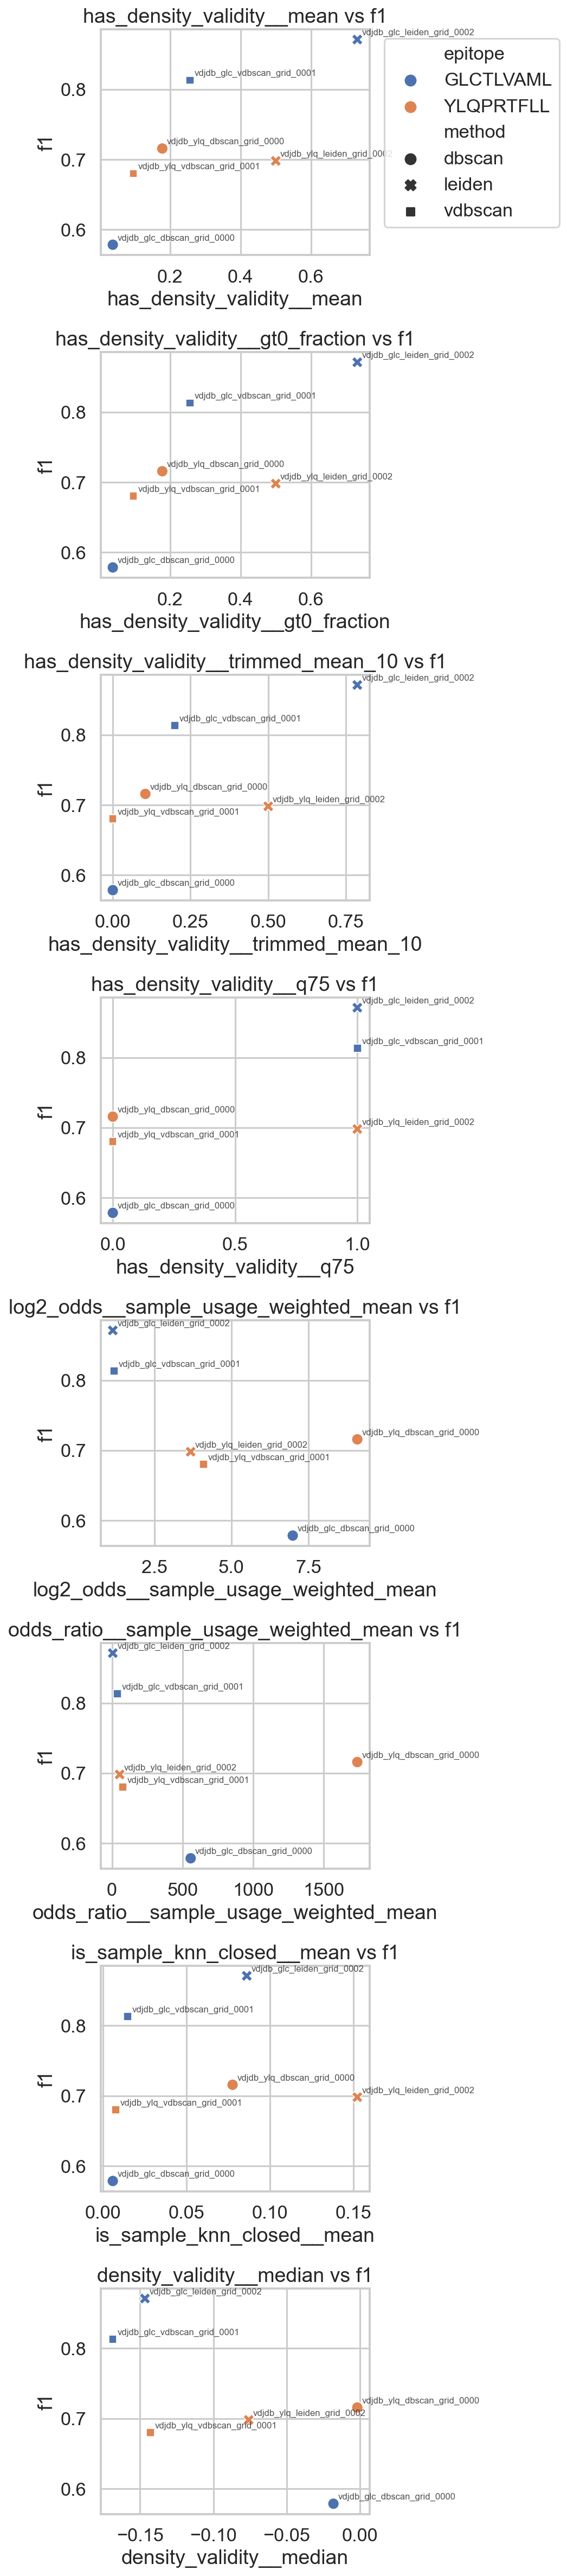

In [9]:
fig, axes = plt.subplots(nrows=len(top_new_metrics), ncols=1, figsize=(7, 4 * len(top_new_metrics)))
if len(top_new_metrics) == 1:
    axes = [axes]
for ax, metric in zip(axes, top_new_metrics):
    frame = run_level_df[[metric, "f1", "epitope", "method", "run_id"]].dropna()
    sns.scatterplot(data=frame, x=metric, y="f1", hue="epitope", style="method", s=100, ax=ax)
    for _, row in frame.iterrows():
        ax.annotate(row["run_id"], (row[metric], row["f1"]), fontsize=8, alpha=0.8, xytext=(4, 4), textcoords="offset points")
    ax.set_title(f"{metric} vs f1")
handles, labels = axes[0].get_legend_handles_labels()
for ax in axes[1:]:
    legend = ax.get_legend()
    if legend is not None:
        legend.remove()
axes[0].legend(handles=handles, labels=labels, bbox_to_anchor=(1.02, 1), loc="upper left")
fig.tight_layout()
fig

## Conceptual new-metric plots

This shortlist is hand-picked by interpretation, not by ranking alone.

In [10]:
conceptual_candidates = [
    "density_validity__mean",
    "density_validity__median",
    "density_validity__trimmed_mean_10",
    "density_validity__q75",
    "dbcv_with_odds__mean",
    "dbcv_with_odds__median",
    "dbcv_with_odds__trimmed_mean_10",
    "redcea_auxiliary_validity__median",
    "is_good_candidate_relaxed__mean",
]
conceptual_metrics = [metric for metric in conceptual_candidates if metric in run_level_df.columns]
conceptual_metrics

['density_validity__mean', 'density_validity__median', 'density_validity__trimmed_mean_10', 'density_validity__q75', 'dbcv_with_odds__mean', 'dbcv_with_odds__median', 'dbcv_with_odds__trimmed_mean_10', 'redcea_auxiliary_validity__median', 'is_good_candidate_relaxed__mean']


In [11]:
conceptual_plot_paths = [plot_metric_vs_f1(run_level_df, metric) for metric in conceptual_metrics]
conceptual_plot_paths

C:\Users\lizzka239\projects\tcrempnet\figures\clustering_strategy\metric_vs_f1\density_validity__mean_vs_f1.png
C:\Users\lizzka239\projects\tcrempnet\figures\clustering_strategy\metric_vs_f1\density_validity__median_vs_f1.png
C:\Users\lizzka239\projects\tcrempnet\figures\clustering_strategy\metric_vs_f1\density_validity__trimmed_mean_10_vs_f1.png
C:\Users\lizzka239\projects\tcrempnet\figures\clustering_strategy\metric_vs_f1\density_validity__q75_vs_f1.png
C:\Users\lizzka239\projects\tcrempnet\figures\clustering_strategy\metric_vs_f1\dbcv_with_odds__mean_vs_f1.png
C:\Users\lizzka239\projects\tcrempnet\figures\clustering_strategy\metric_vs_f1\dbcv_with_odds__median_vs_f1.png
C:\Users\lizzka239\projects\tcrempnet\figures\clustering_strategy\metric_vs_f1\dbcv_with_odds__trimmed_mean_10_vs_f1.png
C:\Users\lizzka239\projects\tcrempnet\figures\clustering_strategy\metric_vs_f1\redcea_auxiliary_validity__median_vs_f1.png
C:\Users\lizzka239\projects\tcrempnet\figures\clustering_strategy\metric_v

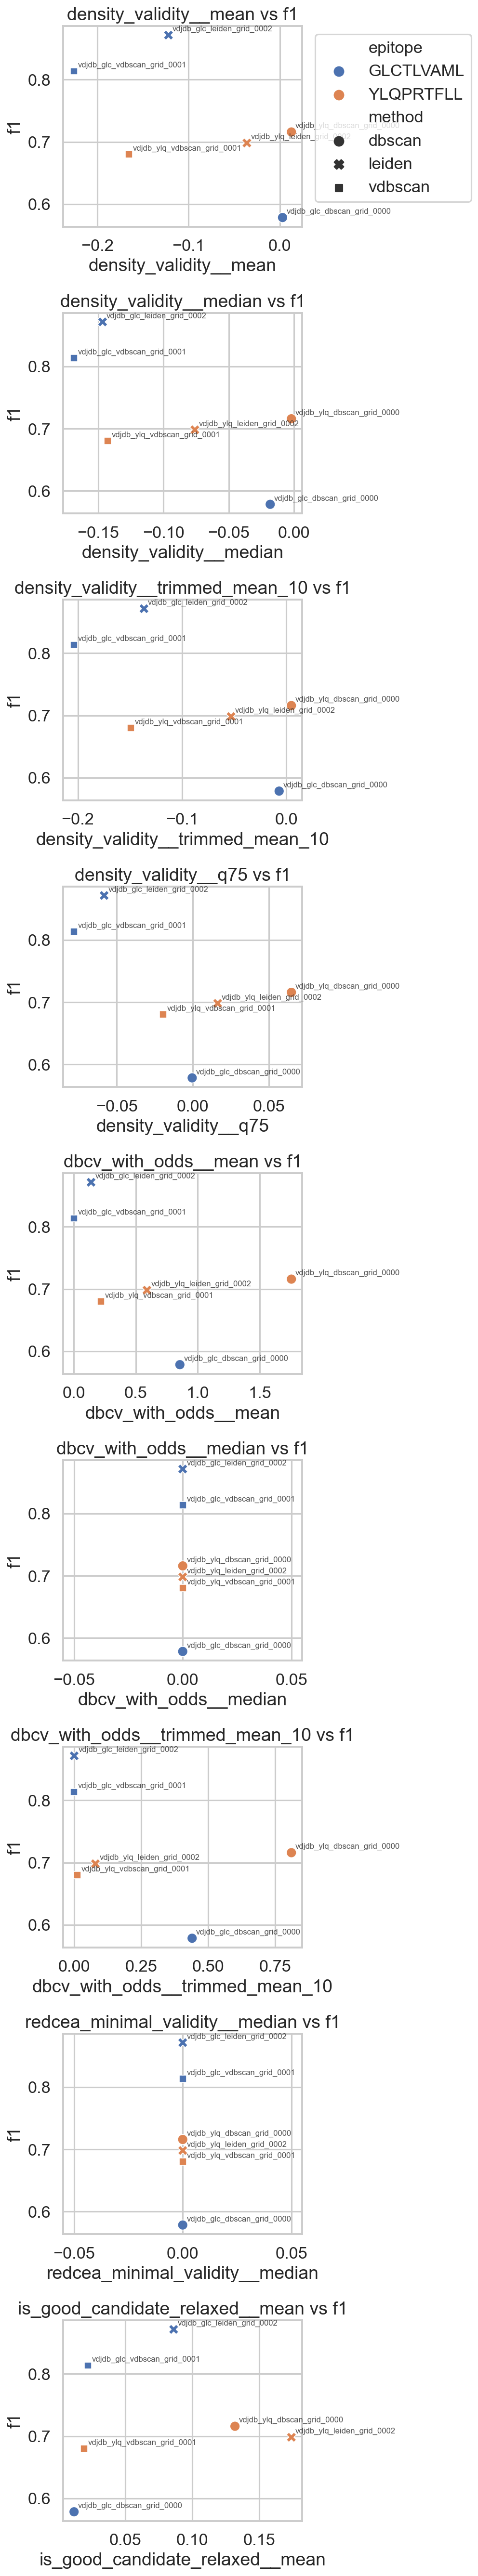

In [12]:
fig, axes = plt.subplots(nrows=len(conceptual_metrics), ncols=1, figsize=(7, 4 * len(conceptual_metrics)))
if len(conceptual_metrics) == 1:
    axes = [axes]
for ax, metric in zip(axes, conceptual_metrics):
    frame = run_level_df[[metric, "f1", "epitope", "method", "run_id"]].dropna()
    sns.scatterplot(data=frame, x=metric, y="f1", hue="epitope", style="method", s=100, ax=ax)
    for _, row in frame.iterrows():
        ax.annotate(row["run_id"], (row[metric], row["f1"]), fontsize=8, alpha=0.8, xytext=(4, 4), textcoords="offset points")
    ax.set_title(f"{metric} vs f1")
handles, labels = axes[0].get_legend_handles_labels()
for ax in axes[1:]:
    legend = ax.get_legend()
    if legend is not None:
        legend.remove()
axes[0].legend(handles=handles, labels=labels, bbox_to_anchor=(1.02, 1), loc="upper left")
fig.tight_layout()
fig

## Notes

- `cluster_level_df` is the raw table for cluster-wise analysis with repeated run-level F1.
- `run_level_df` now includes robust aggregations, not just means.
- Geometry metrics are computed from sample-sample kNN only.
- There are only 6 VDJdb runs in the current table, so correlations remain exploratory.